In [52]:
import keras

In [53]:
from keras import layers

In [54]:
from keras.datasets import mnist 

In [55]:
import numpy as np

In [56]:
encoding_dim=32

In [57]:
input_img=keras.Input(shape=(784,))
encoded=layers.Dense(encoding_dim,activation='relu')(input_img)
decoded=layers.Dense(784,activation='sigmoid')(encoded)

In [58]:
autoencoder= keras.Model(input_img,decoded)


In [59]:
encoder=keras.Model(input_img,encoded)

In [60]:
encoded_input=keras.Input(shape=(encoding_dim,))

In [61]:
decoder_layer=autoencoder.layers[-1]

In [62]:
decoder=keras.Model(encoded_input,decoder_layer(encoded_input))

In [63]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [64]:
(X_train,_),(X_test,_)=mnist.load_data()

In [65]:
X_train.shape

(60000, 28, 28)

In [66]:
X_test.shape

(10000, 28, 28)

In [67]:
X_train=X_train.astype('float32')/255.

In [68]:
X_test=X_test.astype('float32')/255.

In [69]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [70]:
X_train.shape[1:]

(28, 28)

In [71]:
X_train=X_train.reshape((len(X_train),np.prod(X_train.shape[1:])))

In [72]:
X_test=X_test.reshape((len(X_test),np.prod(X_test.shape[1:])))

In [73]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [74]:
print(X_train.shape)

(60000, 784)


In [75]:
autoencoder.fit(X_train,X_train,epochs=50,batch_size=256,
                validation_data=(X_test,X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2759 - val_loss: 0.1889
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1705 - val_loss: 0.1535
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1445 - val_loss: 0.1342
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1289 - val_loss: 0.1216
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1183 - val_loss: 0.1128
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1111 - val_loss: 0.1070
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1062 - val_loss: 0.1028
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1026 - val_loss: 0.0999
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0999 - val_loss: 0.0975
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0980 - val_loss: 0.0959
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0965 - val_loss: 0.0948
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [76]:
encoded_imgs=encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step


In [77]:
decoded_imgs=decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step


In [78]:
import matplotlib.pyplot as plt

In [79]:
#plt.imshow(X_test[0])
#plt.imshow(encoded_imgs[0])
#plt.imshow(encoded_imgs[0])

In [80]:
n=10
plt.figure(figsize=(40,4))

<Figure size 4000x400 with 0 Axes>

<Figure size 4000x400 with 0 Axes>

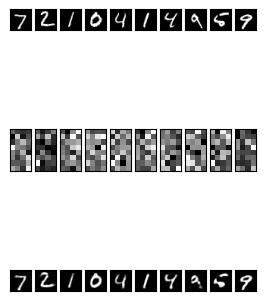

In [82]:
for i in range (10):
    ax =plt.subplot(3,20,i+1)
    plt.imshow(X_test[i].reshape(28,28))
    decoded_imgs
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax=plt.subplot(3,20,i+1+20)
    plt.imshow(encoded_imgs[i].reshape(8,4))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax=plt.subplot(3,20,2*20+i+1)
    plt.imshow(decoded_imgs[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()